In [ ]:
import sys

import matplotlib.pyplot
import numpy
import pandas

sys.path.insert(0, "..")
from runner.utils import load_benchmark_metadata

## Load the results and metadata, and prepare the data for plotting.

In [3]:
# Read the latest results.
results = pandas.read_csv("../results/benchmark_results.csv")
results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,Timeout,Hostname,Run ID,Timestamp,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version,Benchmark1
0,TIMES-GEO-global-netzero,31-20ts,gurobi,13.0.0,2025.0,ok,optimal,30621.769838,17795.476,2.173686e+08,...,86400.0,benchmark-instance-l-19,20251212-run-Ls,2025-12-12 19:27:23.962157,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,gurobi-13.0.0,TIMES-GEO-global-netzero
1,TIMES-GEO-global-netzero,31-20ts,highs-hipo,1.12.0-hipo,2025.0,warning,Not Set,64715.836039,14280.740,NaN,...,86400.0,benchmark-instance-l-19,20251212-run-Ls,2025-12-13 04:01:38.198589,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-hipo-1.12.0-hipo,TIMES-GEO-global-netzero
2,TIMES-GEO-global-netzero,31-20ts,highs-ipx,1.12.0-hipo,2025.0,warning,Not Set,70080.397365,9782.604,NaN,...,86400.0,benchmark-instance-l-19,20251212-run-Ls,2025-12-13 22:03:17.152733,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-ipx-1.12.0-hipo,TIMES-GEO-global-netzero
3,TIMES-GEO-global-netzero,31-20ts,highs,1.12.0,2025.0,ER,unknown,62869.744979,17229.104,0.000000e+00,...,86400.0,benchmark-instance-l-19,20251212-run-Ls,2025-12-14 17:34:17.922231,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-1.12.0,TIMES-GEO-global-netzero
4,TIMES-GEO-global-netzero,31-20ts,scip,10.0.0,2025.0,TO,Timeout,86400.000000,39357.552,NaN,...,86400.0,benchmark-instance-l-19,20251212-run-Ls,2025-12-15 11:05:58.727551,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,scip-10.0.0,TIMES-GEO-global-netzero


In [4]:
# Load the metadata of the benchmarks.
metadata = load_benchmark_metadata("../results/metadata.yaml")
metadata.head()

,Benchmark,Instance,Modelling framework,Model name,Version,Contributor(s)/Source,License,Problem class,Application,Sectoral focus,...,URL,Temporal resolution,Spatial resolution,Realistic,Num. constraints,Num. variables,Skip because,Num. continuous variables,Num. integer variables,Notes
ethos_fine_europe_60tp-175-720ts,ethos_fine_europe_60tp,175-720ts,ETHOS.FINE,ethos.fine.europe,NaN,"Philipp Dunkel, Juelich Systems Analysis (ICE-2)",CC BY 4.0,LP,Infrastructure & Capacity Expansion; Operational,Sector-coupled,...,https://storage.googleapis.com/solver-benchmar...,720 time slices,175 nodes,False,9230938,8141182,TO (needs special solver options),NaN,NaN,NaN
ethos-fine-multi-regional-7tp-8-168ts,ethos-fine-multi-regional-7tp,8-168ts,ETHOS.FINE,Multi-regional example,NaN,https://github.com/FZJ-IEK3-VSA/FINE,CC BY 4.0,MILP,Infrastructure & Capacity Expansion; Operational,Power-only,...,https://storage.googleapis.com/solver-benchmar...,168 time slices,8 nodes,False,91178,55979,NaN,55927.0,52.0,NaN
ethos-fine-multi-regional-7tp-12seg-8-84ts,ethos-fine-multi-regional-7tp-12seg,8-84ts,ETHOS.FINE,Multi-regional example,NaN,https://github.com/FZJ-IEK3-VSA/FINE,CC BY 4.0,MILP,Infrastructure & Capacity Expansion; Operational,Power-only,...,https://storage.googleapis.com/solver-benchmar...,84 time slices,8 nodes,False,64214,33215,NaN,33163.0,52.0,NaN
ethos-fine-energyland-full-timeseries-1-8760ts,ethos-fine-energyland-full-timeseries,1-8760ts,ETHOS.FINE,Energyland example,NaN,https://github.com/FZJ-IEK3-VSA/FINE,CC BY 4.0,LP,Infrastructure & Capacity Expansion; Operational,Sector-coupled,...,https://storage.googleapis.com/solver-benchmar...,8760 time slices,1 node,False,543229,473179,NaN,NaN,NaN,NaN
ethos-fine-energyland-48tp-1-1152ts,ethos-fine-energyland-48tp,1-1152ts,ETHOS.FINE,Energyland example,NaN,https://github.com/FZJ-IEK3-VSA/FINE,CC BY 4.0,LP,Infrastructure & Capacity Expansion; Operational,Sector-coupled,...,https://storage.googleapis.com/solver-benchmar...,1152 time slices,1 node,False,40198,32770,NaN,NaN,NaN,NaN


In [5]:
# Add selected metadata columns to the results dataframe.
results["Variables"] = [
    metadata.loc[b, "Num. variables"] for b in results["bench-size"]
]
results["Constraints"] = [
    metadata.loc[b, "Num. constraints"] for b in results["bench-size"]
]
results["Problem class"] = [
    metadata.loc[b, "Problem class"] for b in results["bench-size"]
]
results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,Timestamp,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version,Benchmark1,Variables,Constraints,Problem class
0,TIMES-GEO-global-netzero,31-20ts,gurobi,13.0.0,2025.0,ok,optimal,30621.769838,17795.476,2.173686e+08,...,2025-12-12 19:27:23.962157,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,gurobi-13.0.0,TIMES-GEO-global-netzero,5422595,5063755,LP
1,TIMES-GEO-global-netzero,31-20ts,highs-hipo,1.12.0-hipo,2025.0,warning,Not Set,64715.836039,14280.740,NaN,...,2025-12-13 04:01:38.198589,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-hipo-1.12.0-hipo,TIMES-GEO-global-netzero,5422595,5063755,LP
2,TIMES-GEO-global-netzero,31-20ts,highs-ipx,1.12.0-hipo,2025.0,warning,Not Set,70080.397365,9782.604,NaN,...,2025-12-13 22:03:17.152733,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-ipx-1.12.0-hipo,TIMES-GEO-global-netzero,5422595,5063755,LP
3,TIMES-GEO-global-netzero,31-20ts,highs,1.12.0,2025.0,ER,unknown,62869.744979,17229.104,0.000000e+00,...,2025-12-14 17:34:17.922231,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-1.12.0,TIMES-GEO-global-netzero,5422595,5063755,LP
4,TIMES-GEO-global-netzero,31-20ts,scip,10.0.0,2025.0,TO,Timeout,86400.000000,39357.552,NaN,...,2025-12-15 11:05:58.727551,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,scip-10.0.0,TIMES-GEO-global-netzero,5422595,5063755,LP


## Group the results by problem size and solver and compute the fraction of solved problems and the shifted geometric mean (SGM) of the runtime.

In [ ]:
# Define the buckets for the number of variables.
buckets = {
    "$10^2$-$10^3$": (1e2, 1e3),
    "$10^3$-$10^4$": (1e3, 1e4),
    "$10^4$-$10^5$": (1e4, 1e5),
    "$10^5$-$10^6$": (1e5, 1e6),
    "$10^6$-$10^7$": (1e6, 1e7),
    "$10^7$-$10^8$": (1e7, 1e8),
}

# Define the features to compute for each bucket.
features = ["num_problems", "fraction_solved", "sgm_runtime", "relative_sgm_runtime"]

# Define the shift to apply to the runtime when computing the SGM runtime.
sgm_shift = 10

# Define the solvers to consider.
# solvers = results["Solver"].unique().tolist()
# solvers.sort()
solvers = ["gurobi", "highs", "highs-ipx", "highs-hipo"]

# Initialize the bucket stats dictionary.
bucket_stats = {
    feature: {solver: {bucket: numpy.nan for bucket in buckets} for solver in solvers}
    for feature in features
}

for solver in solvers:
    # Filter results for the current solver.
    results_to_analyze = results[results["Solver"] == solver]

    # Keep only the latest version of the solver.
    results_to_analyze = results_to_analyze[
        results_to_analyze["Solver Release Year"]
        == results_to_analyze["Solver Release Year"].max()
    ]

    # Keep only LP problems.
    results_to_analyze = results_to_analyze[results_to_analyze["Problem class"] == "LP"]

    for bucket, (lower, upper) in buckets.items():
        # Filter results for the current bucket.
        bucket_results = results_to_analyze[
            (results_to_analyze["Variables"] >= lower)
            & (results_to_analyze["Variables"] < upper)
        ]

        # Compute the number of problems.
        bucket_stats["num_problems"][solver][bucket] = len(bucket_results)

        # Identify the problems where the solver succeeded.
        solver_succeeded = (bucket_results["Status"] == "ok") | (
            (bucket_results["Status"] == "warning")
            & (~bucket_results["Objective Value"].isna())
        )

        # Extract the problems where the solver succeeded.
        bucket_results_solved = bucket_results[solver_succeeded]

        # Compute the fraction of problems solved.
        if len(bucket_results) > 0:
            bucket_stats["fraction_solved"][solver][bucket] = len(
                bucket_results_solved
            ) / len(bucket_results)

        # Penalize the runtime of unsolved problems by multiplying the timeout threshold by 2.
        bucket_results["Runtime (s)"] = bucket_results["Runtime (s)"].where(
            solver_succeeded, 2 * bucket_results["Timeout"]
        )

        # Compute the SGM runtime.
        bucket_stats["sgm_runtime"][solver][bucket] = (
            numpy.exp(numpy.mean(numpy.log(bucket_results["Runtime (s)"] + sgm_shift)))
            - sgm_shift
        )

for bucket in buckets:
    # Find the solver with the largest SGM runtime in the current bucket.
    reference_solver = max(
        solvers, key=lambda s: bucket_stats["sgm_runtime"][s][bucket]
    )

    for solver in solvers:
        # Compute the relative SGM runtime of each solver with respect to the reference solver.
        bucket_stats["relative_sgm_runtime"][solver][bucket] = (
            bucket_stats["sgm_runtime"][reference_solver][bucket]
            / bucket_stats["sgm_runtime"][solver][bucket]
        )

In [ ]:
# Display the fraction of problems solved in each bucket for each solver.
bucket_stats["fraction_solved"]

{'gurobi': {'$10^2$-$10^3$': 1.0,
  '$10^3$-$10^4$': 0.8,
  '$10^4$-$10^5$': 1.0,
  '$10^5$-$10^6$': 0.65,
  '$10^6$-$10^7$': 0.9019607843137255,
  '$10^7$-$10^8$': 0.6666666666666666},
 'highs': {'$10^2$-$10^3$': 1.0,
  '$10^3$-$10^4$': 0.8,
  '$10^4$-$10^5$': 1.0,
  '$10^5$-$10^6$': 0.4,
  '$10^6$-$10^7$': 0.19607843137254902,
  '$10^7$-$10^8$': 0.0},
 'highs-ipx': {'$10^2$-$10^3$': 1.0,
  '$10^3$-$10^4$': 0.8,
  '$10^4$-$10^5$': 1.0,
  '$10^5$-$10^6$': 0.825,
  '$10^6$-$10^7$': 0.5686274509803921,
  '$10^7$-$10^8$': 0.16666666666666666},
 'highs-hipo': {'$10^2$-$10^3$': 1.0,
  '$10^3$-$10^4$': 0.8,
  '$10^4$-$10^5$': 1.0,
  '$10^5$-$10^6$': 0.875,
  '$10^6$-$10^7$': 0.6078431372549019,
  '$10^7$-$10^8$': 0.0}}

In [ ]:
# Display the relative SGM runtime of each solver in each bucket.
bucket_stats["relative_sgm_runtime"]

{'gurobi': {'$10^2$-$10^3$': np.float64(1.0),
  '$10^3$-$10^4$': np.float64(1.0035303781861027),
  '$10^4$-$10^5$': np.float64(1.4239257817094153),
  '$10^5$-$10^6$': np.float64(1.850149070132366),
  '$10^6$-$10^7$': np.float64(74.70817142269819),
  '$10^7$-$10^8$': np.float64(12.552342359079432)},
 'highs': {'$10^2$-$10^3$': np.float64(7.290265391209703),
  '$10^3$-$10^4$': np.float64(1.020217078931284),
  '$10^4$-$10^5$': np.float64(1.0),
  '$10^5$-$10^6$': np.float64(1.0),
  '$10^6$-$10^7$': np.float64(1.0),
  '$10^7$-$10^8$': np.float64(1.0)},
 'highs-ipx': {'$10^2$-$10^3$': np.float64(3.385195925204977),
  '$10^3$-$10^4$': np.float64(1.0468876997244614),
  '$10^4$-$10^5$': np.float64(1.820641876416889),
  '$10^5$-$10^6$': np.float64(3.1366145378352233),
  '$10^6$-$10^7$': np.float64(2.5718743229033616),
  '$10^7$-$10^8$': np.float64(1.1447099758649475)},
 'highs-hipo': {'$10^2$-$10^3$': np.float64(1.0048527430069027),
  '$10^3$-$10^4$': np.float64(1.0),
  '$10^4$-$10^5$': np.float

In [164]:
# Get the number of problems in each bucket for each solver.
num_problems_per_bucket = {
    solver: list(stats.values())
    for solver, stats in bucket_stats["num_problems"].items()
}
num_problems_per_bucket

{'gurobi': [3, 5, 25, 40, 51, 6],
 'highs': [3, 5, 25, 40, 51, 6],
 'highs-ipx': [3, 5, 25, 40, 51, 6],
 'highs-hipo': [3, 5, 25, 40, 51, 6]}

In [139]:
# Get the total problems run by each solver.
{solver: sum(stats.values()) for solver, stats in bucket_stats["num_problems"].items()}

{'gurobi': 130, 'highs': 130, 'highs-ipx': 130, 'highs-hipo': 130}

In [ ]:
# Get the total problems successfully solved by each solver.
{
    solver: int(
        sum(
            bucket_stats["fraction_solved"][solver][bucket]
            * bucket_stats["num_problems"][solver][bucket]
            for bucket in buckets
        )
    )
    for solver in solvers
}

{'gurobi': 108, 'highs': 58, 'highs-ipx': 95, 'highs-hipo': 98}

In [ ]:
# Keep only the latest version of the solver.
results_to_analyze = results[
    results["Solver Release Year"] == results["Solver Release Year"].max()
].copy()

# Keep only LP problems.
results_to_analyze = results_to_analyze[results_to_analyze["Problem class"] == "LP"]

# Identify the problems where the solver succeeded.
solver_succeeded = (results_to_analyze["Status"] == "ok") | (
    (results_to_analyze["Status"] == "warning")
    & (~results_to_analyze["Objective Value"].isna())
)

# Extract the problems where the solver succeeded.
results_to_analyze = results_to_analyze[solver_succeeded]

# Sort the results by becnh-size and solver.
results_to_analyze = results_to_analyze.sort_values(by=["bench-size", "Solver"])

# Initialize a dictionary to store the largest speedup of HiGHS-HIPO over each solver.
largest_speedup = {solver: 0 for solver in solvers if solver != "highs-hipo"}

# Calculate the largest speedup that HiGHS-HIPO achieves over all other solvers.
for problem in results_to_analyze[results_to_analyze["Solver"] == "highs-hipo"][
    "bench-size"
]:
    for solver in solvers:
        if (
            solver != "highs-hipo"
            and problem
            in results_to_analyze[results_to_analyze["Solver"] == solver][
                "bench-size"
            ].to_list()
        ):
            # Get the runtime of the current solver and HiGHS-HIPO for the current problem.
            solver_runtime = results_to_analyze[
                (results_to_analyze["bench-size"] == problem)
                & (results_to_analyze["Solver"] == solver)
            ]["Runtime (s)"].values[0]
            hipo_runtime = results_to_analyze[
                (results_to_analyze["bench-size"] == problem)
                & (results_to_analyze["Solver"] == "highs-hipo")
            ]["Runtime (s)"].values[0]

            # Compute the speedup of HiGHS-HIPO over the current solver.
            speedup = solver_runtime / hipo_runtime

            # Update the largest speedup if the current speedup is larger.
            if speedup > largest_speedup[solver]:
                largest_speedup[solver] = speedup

# Display the largest speedup of HiGHS-HIPO over each solver.
largest_speedup

{'gurobi': np.float64(7.600905283916516),
 'highs': np.float64(52.96458500255611),
 'highs-ipx': np.float64(10.052998076268205)}

In [136]:
# Get the poblems with more than 10^7 variables.
results[results["Variables"] > 1e7]["bench-size"].unique().tolist()

['pypsa-de-sec-trex_copt-50-1h',
 'pypsa-de-sec-trex_vopt-50-1h',
 'genx-elec_co2-15-168h',
 'genx-elec_trex-15-168h',
 'genx-elec_trex_co2-15-168h',
 'SWITCH-China-open-model-32-433ts']

## For each problem size and solver, plot the number of problems, the fraction of solved problems, and the SGM of the runtime. Use a log scale for the runtime.

In [121]:
# Define the color map for the solvers.
color_map = {
    "cbc": "#F9CD5A",  # yellow
    "glpk": "#7C3AED",  # purple
    "gurobi": "#F66C49",  # red
    "highs": "#43BF94",  # green
    "highs-hipo": "#F759B8",  # magenta
    "highs-ipx": "#6D712E",  # green-brown
    "scip": "#3B82F6",  # blue
}

# Define the marker map for the solvers.
marker_map = {
    "cbc": "o",  # yellow
    "glpk": "s",  # purple
    "gurobi": "D",  # red
    "highs": "^",  # green
    "highs-hipo": "v",  # magenta
    "highs-ipx": "P",  # green-brown
    "scip": "X",  # blue
}

# Define the name map for the solvers.
name_map = {
    "cbc": "CBC",
    "glpk": "GLPK",
    "gurobi": "Gurobi with\ndefault options",
    "highs": "HiGHS-simplex",
    "highs-hipo": "HiGHS-HiPO",
    "highs-ipx": "HiGHS-IPX",
    "scip": "SCIP",
}

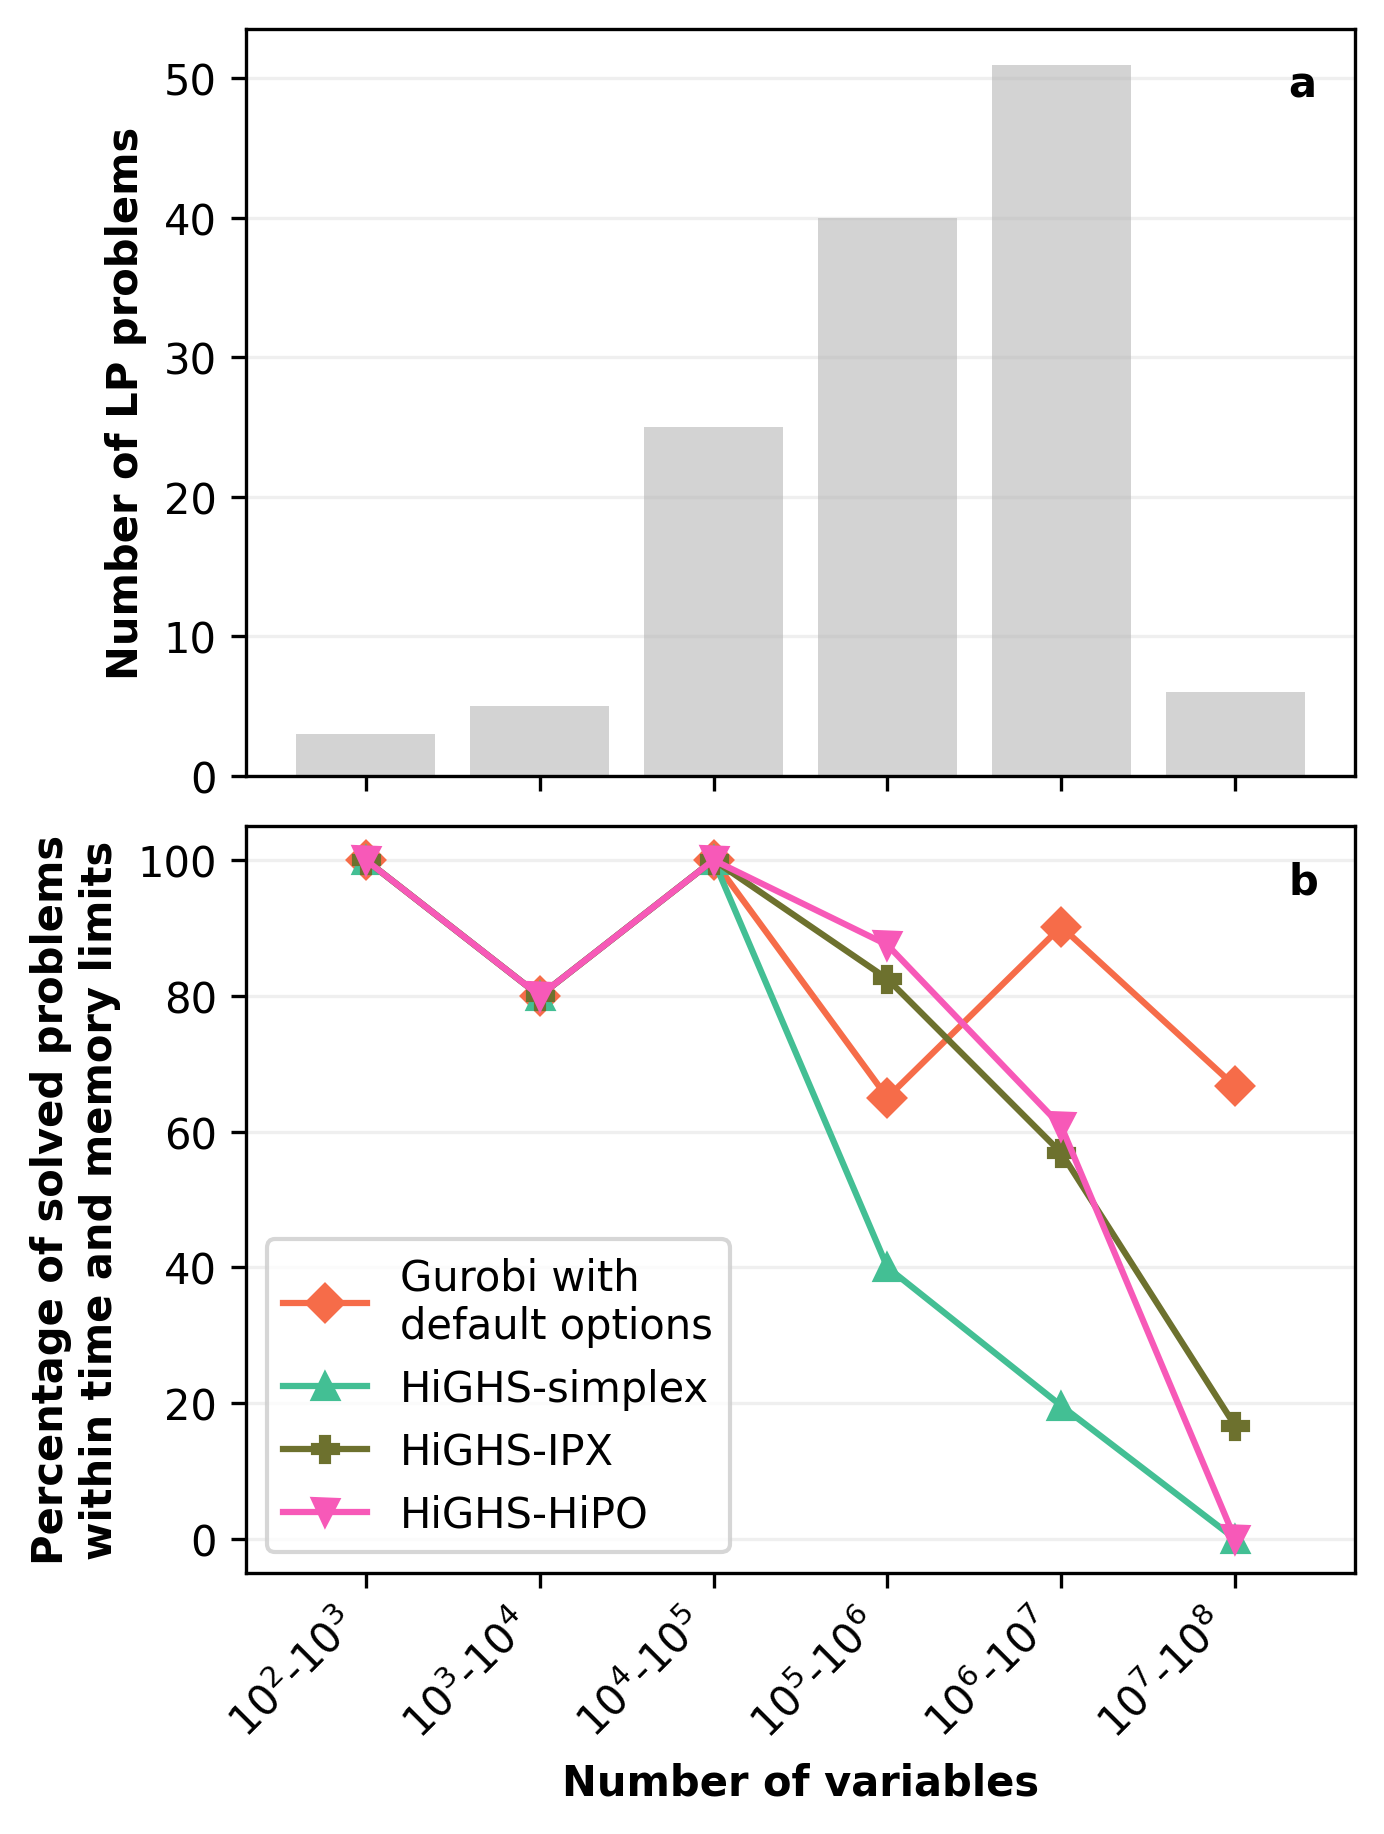

In [ ]:
# Initialize the figure and axes for the plot.
fig, axs = matplotlib.pyplot.subplots(
    2, 1, figsize=(4.5, 6), dpi=300, sharex=True, constrained_layout=True
)

# If all solvers have the same number of problems in each bucket, use a bar plot for the number of problems in each bucket. Otherwise, use a line plot.
if len(set(tuple(v) for v in num_problems_per_bucket.values())):
    # Add a bar plot for the number of problems in each bucket.
    axs[0].bar(
        range(len(buckets)),
        list(num_problems_per_bucket.values())[0],
        color="lightgrey",
        label="Number of problems",
    )
    axs[0].set_ylabel("Number of LP problems", weight="bold")
    axs[0].grid(axis="y", alpha=0.2)
else:
    # Add a line plot for the number of problems in each bucket.
    for i, (solver, stats) in enumerate(bucket_stats["num_problems"].items()):
        buckets_list = list(stats.keys())
        values = list(stats.values())
        axs[0].plot(
            range(len(buckets_list)),
            values,
            marker=marker_map.get(solver, None),
            label=name_map.get(solver, solver),
            color=color_map.get(solver, None),
        )
    axs[0].set_ylabel("Number of problems", weight="bold")
    axs[0].grid(axis="y", alpha=0.2)

# Add the panel letter.
axs[0].text(0.94, 0.91, "a", transform=axs[0].transAxes, fontsize=10, weight="bold")

# Add a line plot for the percentage of prooblems solved in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["fraction_solved"].items()):
    buckets_list = stats.keys()
    values = numpy.array(list(stats.values())) * 100
    axs[1].plot(
        range(len(buckets_list)),
        values,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[1].set_ylabel(
    "Percentage of solved problems\nwithin time and memory limits", weight="bold"
)
axs[1].set_xticks(
    range(len(buckets)), labels=list(buckets.keys()), rotation=45, ha="right"
)
axs[1].set_xlabel("Number of variables", weight="bold")
axs[1].grid(axis="y", alpha=0.2)
axs[1].legend(loc="lower left")

# Add the panel letter.
axs[1].text(0.94, 0.91, "b", transform=axs[1].transAxes, fontsize=10, weight="bold")

# Save the figure.
fig.savefig("fraction_solved_by_problem_size.png", bbox_inches="tight", dpi=300)

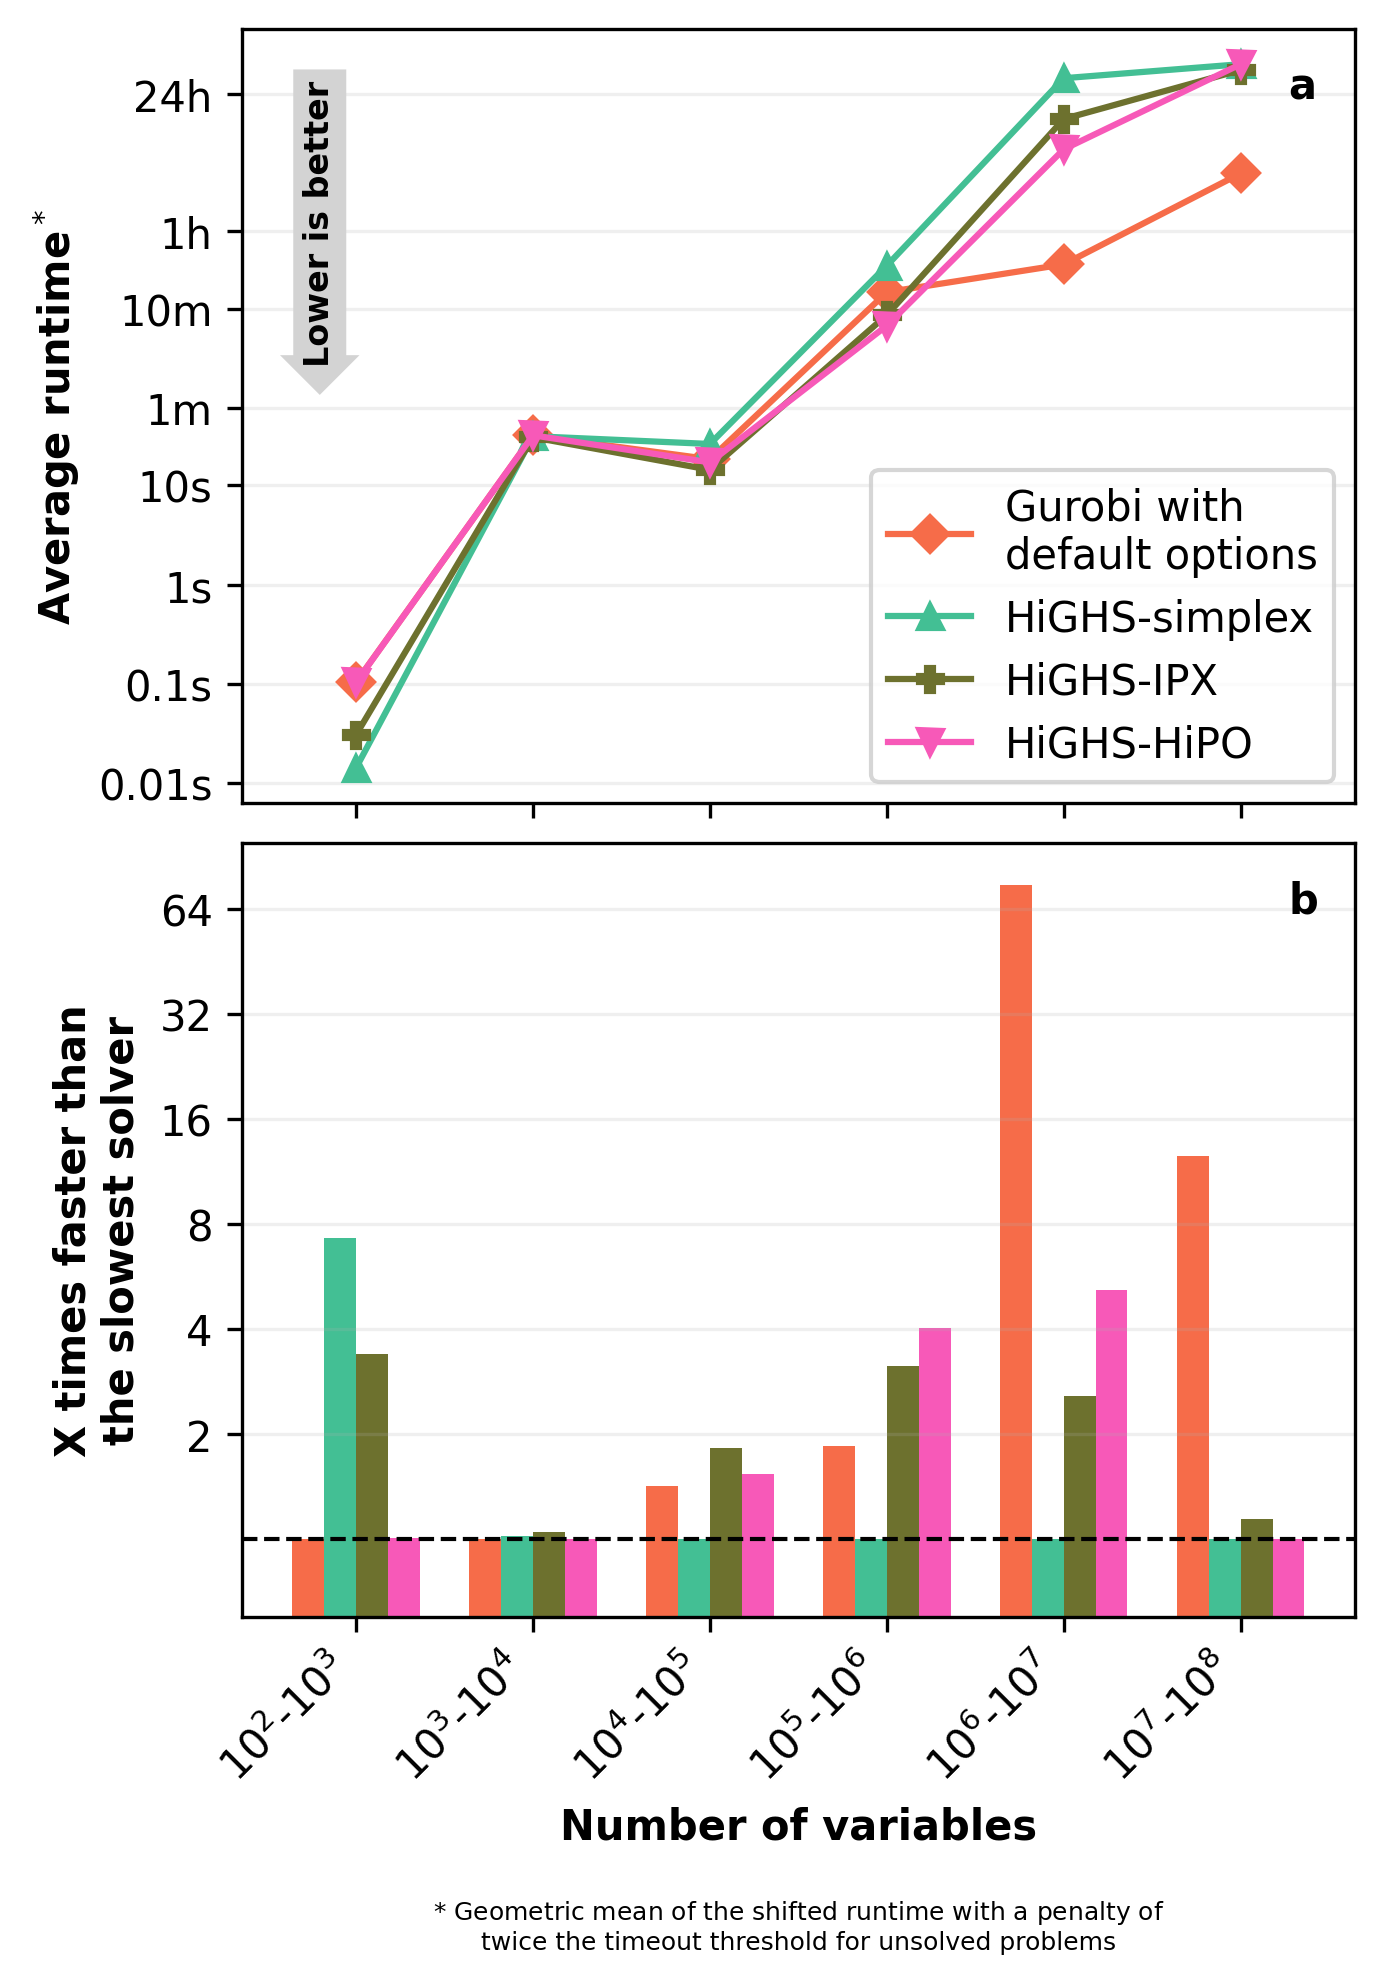

In [167]:
# Initialize the figure and axes for the plot.
fig, axs = matplotlib.pyplot.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=300, sharex=True, constrained_layout=True
)

# Add a line plot for the SGM runtime in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["sgm_runtime"].items()):
    buckets_list = list(stats.keys())
    values = list(stats.values())
    axs[0].plot(
        range(len(buckets_list)),
        values,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[0].set_yscale("log")
axs[0].minorticks_off()
axs[0].set_ylabel("Average runtime$^*$", weight="bold")
axs[0].set_yticks(
    [0.01, 0.1, 1, 10, 60, 600, 3600, 86400],
    ["0.01s", "0.1s", "1s", "10s", "1m", "10m", "1h", "24h"],
)
axs[0].legend(loc="lower right")
axs[0].grid(axis="y", alpha=0.2)
axs[0].text(
    0.07,
    0.75,
    "Lower is better",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    weight="bold",
    fontsize=8,
    rotation=90,
    bbox=dict(boxstyle="larrow", facecolor="lightgrey", edgecolor="none"),
)

# Add the panel letter.
axs[0].text(0.94, 0.91, "a", transform=axs[0].transAxes, fontsize=10, weight="bold")

# Add a bar plot for the relative SGM runtime in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["relative_sgm_runtime"].items()):
    buckets_list = list(stats.keys())
    values = list(stats.values())
    axs[1].bar(
        [j + -0.27 + 0.18 * i for j in range(len(buckets_list))],
        values,
        width=0.18,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[1].axhline(1, color="black", linestyle="--", linewidth=1)
axs[1].set_yscale("log", base=2)
axs[1].set_ylim(0.6, 99)
axs[1].set_yticks([2, 4, 8, 16, 32, 64], ["2", "4", "8", "16", "32", "64"])
axs[1].minorticks_off()
axs[1].set_ylabel("X times faster than\nthe slowest solver", weight="bold")
axs[1].set_xticks(range(len(buckets_list)), buckets_list, rotation=45, ha="right")
axs[1].set_xlabel("Number of variables", weight="bold")
axs[1].grid(axis="y", alpha=0.2)

# Add the panel letter.
axs[1].text(0.94, 0.91, "b", transform=axs[1].transAxes, fontsize=10, weight="bold")

# Add a note to explain the meaning of the SGM runtime.
axs[1].text(
    0.5,
    -0.4,
    "$*$ Geometric mean of the shifted runtime with a penalty of\ntwice the timeout threshold for unsolved problems",
    transform=axs[1].transAxes,
    ha="center",
    va="center",
    fontsize=6,
    clip_on=False,
)

# Save the figure.
fig.savefig("sgm_runtime_by_problem_size.png", bbox_inches="tight", dpi=300)